# Q3 — Career Switching vs. Salary and Satisfaction

**Question:** Do people who switched careers into data differ in salary or satisfaction from those who didn't?

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid", palette="mako")
plt.rcParams["figure.dpi"] = 110

OUT = Path("charts")
OUT.mkdir(exist_ok=True)

# Load and clean - same cleaning decision made in the SQL phase:
# blank education values become the literal string 'None'
df = pd.read_csv("DataProfessionalSurvey_Clean.csv")
df["education"] = df["education"].fillna("None")
df["country"] = df["country"].str.strip()
df["role_name"] = df["role_name"].str.strip()

print(f"{len(df)} respondents loaded.")
df.head()

630 respondents loaded.


,respondent_id,date_taken,time_taken,time_spent,role_name,switched_careers,salary_band,salary_midpoint,industry,fav_language,...,satisfaction_mobility,satisfaction_learning,satisfaction_composite,difficulty_breaking_in,top_job_priority,gender,age,country,education,ethnicity
0,62a33b3db4da29969c62df3d,6/10/2022,8:38,0:00:44,Data Analyst,Yes,106-125,115500,Healthcare,Python,...,5.00,7.00,7.00,Very Difficult,Remote Work,Male,26,United States,None,White
1,62a33ba1bae91e4b8b82e35c,6/10/2022,8:40,0:01:30,Data Analyst,No,41-65,53000,Finance,R,...,1.00,3.00,2.33,Very Difficult,Remote Work,Male,36,Canada,None,Asian
2,62a33c2cbc6861bf3176bec1,6/10/2022,8:42,0:02:18,Data Engineer,No,0-40,20000,Other,Python,...,7.00,7.00,5.67,Easy,Good Work/Life Balance,Male,23,Rest of the world,None,Black
3,62a33c8624a26260273822f9,6/10/2022,8:43,0:02:10,Other,Yes,150 - 225,187500,Finance,R,...,7.00,10.00,8.33,Very Easy,Remote Work,Female,35,Canada,None,White
4,62a33c91f3072dd892621e03,6/10/2022,8:44,0:01:51,Data Analyst,Yes,41 - 65,53000,Healthcare,R,...,0.00,1.00,2.33,Difficult,Better Salary,Male,44,United States,None,Black


In [2]:
career_switch = df.groupby("switched_careers").agg(
    median_salary=("salary_midpoint", "median"),
    mean_salary=("salary_midpoint", "mean"),
    mean_composite_satisfaction=("satisfaction_composite", "mean"),
    n=("respondent_id", "count"),
)
career_switch

,median_salary,mean_salary,mean_composite_satisfaction,n
switched_careers,,,,
No,"53,000.00","52,577.52",5.01,258
Yes,"53,000.00","54,956.99",5.41,372


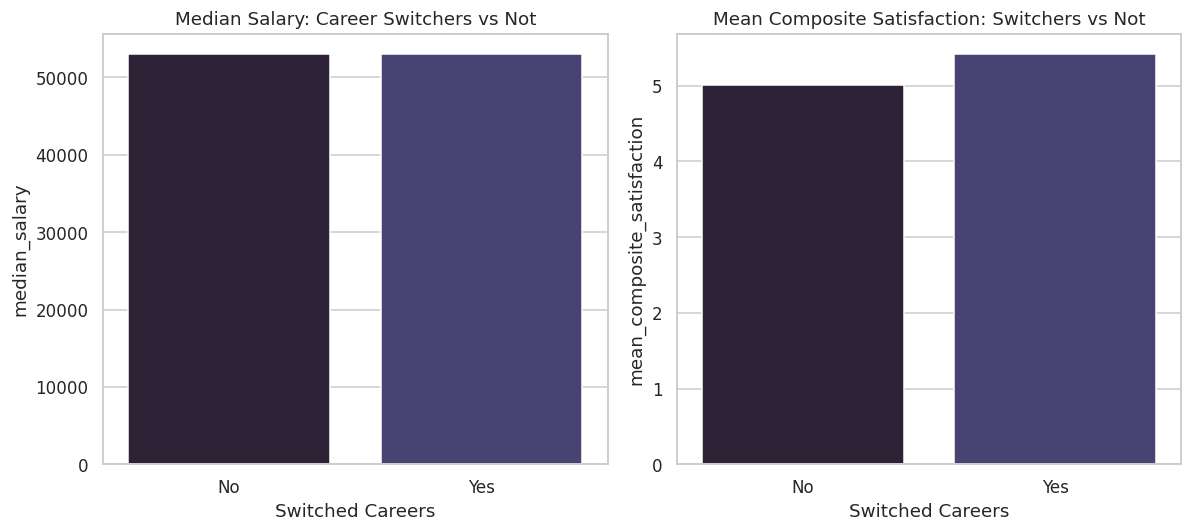

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 5))
data = career_switch.reset_index()

sns.barplot(data=data, x="switched_careers", y="median_salary", ax=axes[0],
            hue="switched_careers", legend=False)
axes[0].set_title("Median Salary: Career Switchers vs Not")
axes[0].set_xlabel("Switched Careers")

sns.barplot(data=data, x="switched_careers", y="mean_composite_satisfaction", ax=axes[1],
            hue="switched_careers", legend=False)
axes[1].set_title("Mean Composite Satisfaction: Switchers vs Not")
axes[1].set_xlabel("Switched Careers")

fig.tight_layout()
fig.savefig(OUT / "q3_career_switch_impact.png", bbox_inches="tight")
plt.show()

**Takeaway:** Career switchers report slightly *higher* median satisfaction (5.41 vs 5.01) and comparable salary to non-switchers — switching doesn't appear to be a costly move in this sample.